In [62]:
import os
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from random import seed, randrange, sample
import math
import numpy as np
from math import sqrt, exp
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
import random
from tqdm import tqdm
from collections import Counter

In [63]:
from collections import Counter

In [64]:
df = pd.read_excel("Data for SPSS.xlsx")
df.head()

,Faculty,Gender,Academic year,Age group,Learning time before COVID-19,Learning time during COVID-19,No. of Siblings,Location of residence,Source of tuition fees,Cumulative average (GPA),...,TM2,TM3,HS1,HS2,HS3,HS4,SE1,SE2,SE3,SE4
0,5,1,2,1,2,2,1,3,1,1,...,3,4,2,4,4,3,4,4,3,4
1,5,1,1,1,1,1,4,3,2,1,...,5,5,5,5,5,2,2,2,2,4
2,5,1,2,1,2,1,2,3,1,1,...,4,4,2,4,4,3,3,4,4,4
3,8,1,3,2,2,2,3,3,1,1,...,4,4,4,4,4,4,4,4,4,4
4,6,1,2,2,2,1,3,2,1,2,...,2,3,5,5,5,5,4,4,1,2


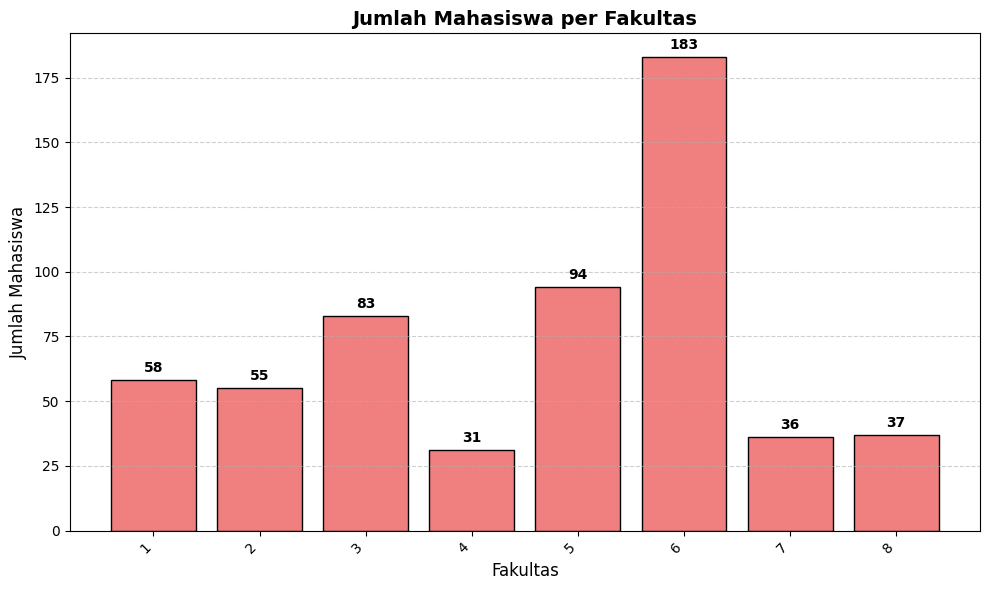

=== Jumlah Mahasiswa per Fakultas ===
   Faculty  Jumlah Mahasiswa
0        6               183
1        5                94
2        3                83
3        1                58
4        2                55
5        8                37
6        7                36
7        4                31


In [65]:
# jumlah mahasiswa/fakultas
faculty_counts = df['Faculty'].value_counts().reset_index()
faculty_counts.columns = ['Faculty', 'Jumlah Mahasiswa']

plt.figure(figsize=(10, 6))
bars = plt.bar(faculty_counts['Faculty'], faculty_counts['Jumlah Mahasiswa'], color='lightcoral', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, yval + 2,   # posisi teks di atas batang
        int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Jumlah Mahasiswa per Fakultas', fontsize=14, fontweight='bold')
plt.xlabel('Fakultas', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("=== Jumlah Mahasiswa per Fakultas ===")
print(faculty_counts)

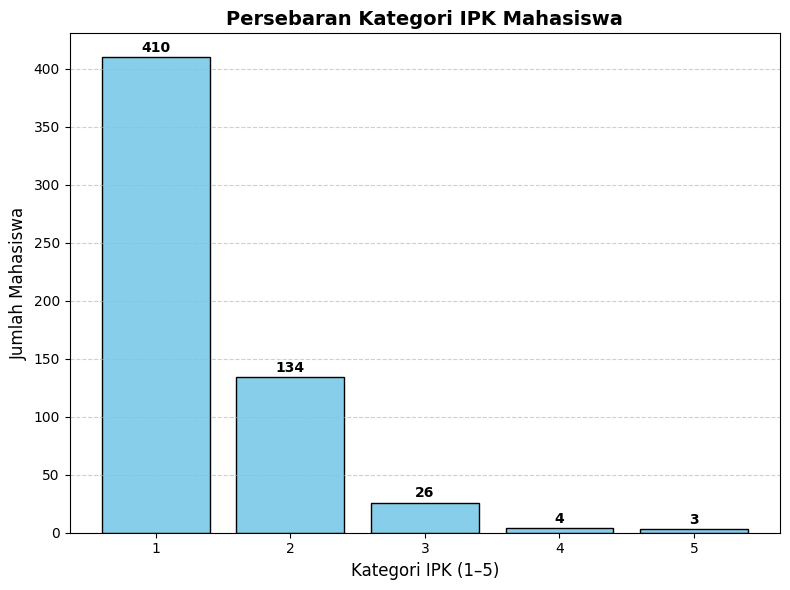

In [66]:
# jumlah mahasiswa/kategori IPK
gpa_counts = df['Cumulative average (GPA)'].value_counts().sort_index().reset_index()
gpa_counts.columns = ['Kategori IPK', 'Jumlah Mahasiswa']

plt.figure(figsize=(8,6))
bars = plt.bar(gpa_counts['Kategori IPK'], gpa_counts['Jumlah Mahasiswa'], color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, yval + 2,
        int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title('Persebaran Kategori IPK Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Kategori IPK (1–5)', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [67]:
# Cek tipe data dan jumlah nilai kosong
df.info()
print("\nJumlah nilai kosong per kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Faculty                        577 non-null    int64
 1   Gender                         577 non-null    int64
 2   Academic year                  577 non-null    int64
 3   Age group                      577 non-null    int64
 4   Learning time before COVID-19  577 non-null    int64
 5   Learning time during COVID-19  577 non-null    int64
 6   No. of Siblings                577 non-null    int64
 7   Location of residence          577 non-null    int64
 8   Source of tuition fees         577 non-null    int64
 9   Cumulative average (GPA)       577 non-null    int64
 10  Daily Internet usage           577 non-null    int64
 11  Purpose of internet usage      577 non-null    int64
 12  Devices often use              577 non-null    int64
 13  Parental education  

In [68]:
ordinal_cols = [
    'Age group', 'Academic year', 'Cumulative average (GPA)',
    'Daily Internet usage', 'Learning time before COVID-19',
    'Learning time during COVID-19', 'Parental education', 'No. of Siblings'
]

nominal_cols = [
    'Faculty', 'Gender', 'Location of residence',
    'Source of tuition fees ', 'Devices often use', 'Parental occupation'
]

# encode nominal
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# encode ordonal
ord_enc = OrdinalEncoder()
df_encoded[ordinal_cols] = ord_enc.fit_transform(df_encoded[ordinal_cols])

df_encoded.head()

,Academic year,Age group,Learning time before COVID-19,Learning time during COVID-19,No. of Siblings,Cumulative average (GPA),Daily Internet usage,Purpose of internet usage,Parental education,GS1,...,Location of residence_3,Source of tuition fees _2,Source of tuition fees _3,Devices often use_2,Devices often use_3,Devices often use_4,Parental occupation_2,Parental occupation_3,Parental occupation_4,Parental occupation_5
0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,3,1.0,4,...,True,False,False,True,False,False,False,False,True,False
1,0.0,0.0,0.0,0.0,3.0,0.0,1.0,3,1.0,5,...,True,True,False,True,False,False,False,False,False,False
2,1.0,0.0,1.0,0.0,1.0,0.0,2.0,3,1.0,4,...,True,False,False,True,False,False,False,False,True,False
3,2.0,1.0,1.0,1.0,2.0,0.0,2.0,3,1.0,4,...,True,False,False,False,True,False,False,False,True,False
4,1.0,1.0,1.0,0.0,2.0,1.0,1.0,3,1.0,4,...,False,False,False,False,True,False,False,False,True,False


In [69]:
# Kolom numerik kontinu yang valid untuk outlier detection
outlier_cols = [
    'Daily Internet usage',
    'Learning time before COVID-19',
    'Learning time during COVID-19',
    'No. of Siblings'
]

# Pastikan kolom benar-benar ada di df_encoded
outlier_cols = [col for col in outlier_cols if col in df_encoded.columns]
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) &
            (df_clean[col] <= upper_bound)
        ]

    return df_clean

rows_before = df_encoded.shape[0]

df_encoded = remove_outliers_iqr(df_encoded, outlier_cols)

rows_after = df_encoded.shape[0]

print("=== OUTLIER REMOVAL SUMMARY ===")
print(f"Jumlah data sebelum : {rows_before}")
print(f"Jumlah data sesudah : {rows_after}")
print(f"Data dihapus        : {rows_before - rows_after}")
print(f"Persentase dihapus  : {(rows_before - rows_after) / rows_before * 100:.2f}%")


=== OUTLIER REMOVAL SUMMARY ===
Jumlah data sebelum : 577
Jumlah data sesudah : 531
Data dihapus        : 46
Persentase dihapus  : 7.97%


In [70]:
print("=== JUMLAH DATA PER LABEL IPK ===")
print(df_encoded['Cumulative average (GPA)'].value_counts().sort_index())

print("\n=== PERSENTASE DATA PER LABEL IPK ===")
print(df_encoded['Cumulative average (GPA)']
      .value_counts(normalize=True)
      .sort_index()
      * 100)

=== JUMLAH DATA PER LABEL IPK ===
Cumulative average (GPA)
0.0    377
1.0    124
2.0     24
3.0      4
4.0      2
Name: count, dtype: int64

=== PERSENTASE DATA PER LABEL IPK ===
Cumulative average (GPA)
0.0    70.998117
1.0    23.352166
2.0     4.519774
3.0     0.753296
4.0     0.376648
Name: proportion, dtype: float64


In [71]:
def merge_ipk_raw(label):
    if label == 0:
        return 'tinggi'
    elif label in [1]:
        return 'menengah'
    elif label in [2, 3, 4]:
        return 'rendah'
    else:
        return None

df_encoded['IPK_group'] = df_encoded['Cumulative average (GPA)'].apply(merge_ipk_raw)


In [72]:
print(df_encoded['IPK_group'].value_counts(dropna=False))

IPK_group
tinggi      377
menengah    124
rendah       30
Name: count, dtype: int64


In [73]:
ipk_final_map = {
    'rendah': 0,
    'menengah': 1,
    'tinggi': 2
}

df_encoded['IPK_final'] = df_encoded['IPK_group'].map(ipk_final_map)

print("=== DISTRIBUSI IPK FINAL ===")
print(df_encoded['IPK_final'].value_counts().sort_index())

print("\n=== PERSENTASE ===")
print(
    df_encoded['IPK_final']
    .value_counts(normalize=True)
    .sort_index() * 100
)

=== DISTRIBUSI IPK FINAL ===
IPK_final
0     30
1    124
2    377
Name: count, dtype: int64

=== PERSENTASE ===
IPK_final
0     5.649718
1    23.352166
2    70.998117
Name: proportion, dtype: float64


In [74]:
oslq_cols = [col for col in df_encoded.columns if col.startswith(('GS', 'EH', 'TS', 'TM', 'HR', 'SE'))]
print("Kolom OSLQ:", oslq_cols)

# scaling
scaler = MinMaxScaler()

# Fit dan transform kolom OSLQ
df_encoded[oslq_cols] = scaler.fit_transform(df_encoded[oslq_cols])

# Sebelum scaling
print("Nilai sebelum scaling:")
print(df[oslq_cols].describe())

# Sesudah scaling
print("\nNilai sesudah scaling:")
print(df_encoded[oslq_cols].describe())

Kolom OSLQ: ['GS1', 'GS2', 'GS3', 'GS4', 'GS5', 'TS1', 'TS2', 'TS3', 'TS4', 'TM1', 'TM2', 'TM3', 'SE1', 'SE2', 'SE3', 'SE4']
Nilai sebelum scaling:
              GS1         GS2         GS3         GS4         GS5         TS1  \
count  577.000000  577.000000  577.000000  577.000000  577.000000  577.000000   
mean     4.102253    3.970537    3.679376    4.143847    3.792028    3.880416   
std      0.675677    0.777839    0.916368    0.730131    0.974540    0.913583   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      4.000000    4.000000    3.000000    4.000000    3.000000    3.000000   
50%      4.000000    4.000000    4.000000    4.000000    4.000000    4.000000   
75%      5.000000    4.000000    4.000000    5.000000    4.000000    5.000000   
max      5.000000    5.000000    5.000000    5.000000    5.000000    5.000000   

              TS2         TS3         TS4         TM1         TM2         TM3  \
count  577.000000  577.000000  577.000000

In [75]:
df_encoded[oslq_cols].head()

,GS1,GS2,GS3,GS4,GS5,TS1,TS2,TS3,TS4,TM1,TM2,TM3,SE1,SE2,SE3,SE4
0,0.75,0.75,0.75,0.75,0.75,0.50,0.50,0.50,0.50,0.75,0.50,0.75,0.75,0.75,0.50,0.75
2,0.75,0.75,0.75,0.75,0.50,0.75,0.75,0.50,0.50,0.75,0.75,0.75,0.50,0.75,0.75,0.75
3,0.75,0.75,0.75,0.75,0.25,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75
4,0.75,0.50,0.25,0.75,0.75,1.00,0.00,0.25,0.50,0.25,0.25,0.50,0.75,0.75,0.00,0.25
5,0.75,0.75,0.75,0.75,0.75,0.50,0.75,0.75,0.50,0.75,0.50,0.75,0.75,0.75,0.25,0.75


In [76]:
X = df_encoded.drop(columns=['Cumulative average (GPA)', 'IPK_group', 'IPK_final'])
y = df_encoded['IPK_final']

print("jumlah fitur: ", X.shape[1])

jumlah fitur:  51


In [77]:
# Membagi data menjadi train (80%) dan test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

label_mapping = {
    0: "<3.0",
    1: "3.0-3.49",
    2: "3.5+"
}


# Menampilkan hasil split
print("Jumlah data latih :", X_train.shape[0])
print("Jumlah data uji    :", X_test.shape[0])
print("Proporsi kelas di data latih:\n", y_train.replace(label_mapping).value_counts(normalize=True))
print("\nProporsi kelas di data uji:\n", y_test.replace(label_mapping).value_counts(normalize=True))

Jumlah data latih : 424
Jumlah data uji    : 107
Proporsi kelas di data latih:
 IPK_final
3.5+        0.709906
3.0-3.49    0.233491
<3.0        0.056604
Name: proportion, dtype: float64

Proporsi kelas di data uji:
 IPK_final
3.5+        0.710280
3.0-3.49    0.233645
<3.0        0.056075
Name: proportion, dtype: float64


In [78]:
# Inisialisasi SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)

# Terapkan SMOTE hanya pada data training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Tampilkan distribusi dengan label kategori
print("Distribusi sebelum SMOTE (kategori):")
print(y_train.replace(label_mapping).value_counts())

print("\nDistribusi sesudah SMOTE (kategori):")
print(y_train_resampled.replace(label_mapping).value_counts())

Distribusi sebelum SMOTE (kategori):
IPK_final
3.5+        301
3.0-3.49     99
<3.0         24
Name: count, dtype: int64

Distribusi sesudah SMOTE (kategori):
IPK_final
3.5+        301
3.0-3.49    301
<3.0        301
Name: count, dtype: int64


In [79]:
# fungsi gini index
def gini_index(groups, classes):
    n_instances = float(sum([len(group) for group in groups]))
    gini = 0.0
    for group in groups:
        size = float(len(group))
        if size == 0:
            continue
        score = 0.0
        class_values = [row[-1] for row in group]
        for class_val in classes:
            p = class_values.count(class_val) / size
            score += p * p
        gini += (1.0 - score) * (size / n_instances)
    return gini

In [80]:
def test_split(index, value, dataset):
    left, right = [], []
    for row in dataset:
        if row[index] < value:
            left.append(row)
        else:
            right.append(row)
    return left, right

In [81]:
# fungsi split data
def get_split(dataset):
    class_values = list(set(row[-1] for row in dataset))
    b_index, b_value, b_score, b_groups = 999, 999, 999, None
    for index in range(len(dataset[0]) - 1):
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini = gini_index(groups, class_values)
            if gini < b_score:
                b_index, b_value, b_score, b_groups = index, row[index], gini, groups
    return {'index': b_index, 'value': b_value, 'groups': b_groups}

In [82]:
# fungsi node terminal
def to_terminal(group):
    outcomes = [row[-1] for row in group]
    return max(set(outcomes), key=outcomes.count)

In [83]:
# fungsi split node rekursif
def split(node, max_depth, min_size, depth):
    left, right = node['groups']
    del(node['groups'])

    # jika salah satu sisi kosong -> buat leaf
    if not left or not right:
        outcomes = [row[-1] for row in left + right]
        node['left'] = node['right'] = max(set(outcomes), key=outcomes.count)
        return

    # stop jika kedalaman maksimum
    if depth >= max_depth:
        node['left'], node['right'] = to_terminal(left), to_terminal(right)
        return

    # split sisi kiri dan kanan
    if len(left) <= min_size:
        node['left'] = to_terminal(left)
    else:
        node['left'] = get_split_rf(left, n_features)
        # ⬇ tambahkan ini supaya gain tersimpan di semua node bawah
        split(node['left'], max_depth, min_size, depth + 1)

    if len(right) <= min_size:
        node['right'] = to_terminal(right)
    else:
        node['right'] = get_split_rf(right, n_features)
        # ⬇ sama, recursive untuk kanan
        split(node['right'], max_depth, min_size, depth + 1)

In [84]:
# fungsi build tree
def build_tree(train, max_depth, min_size):
    root = get_split(train)
    split(root, max_depth, min_size, 1)
    return root

In [85]:
# fungsi predict
def predict(node, row):
    if row[node['index']] < node['value']:
        if isinstance(node['left'], dict):
            return predict(node['left'], row)
        else:
            return node['left']
    else:
        if isinstance(node['right'], dict):
            return predict(node['right'], row)
        else:
            return node['right']

In [86]:
# pipeline & testing
def decision_tree(train, test, max_depth, min_size):
    tree = build_tree(train, max_depth, min_size)
    predictions = [predict(tree, row) for row in test]
    return predictions

In [87]:
# fungsi bootstrap sample
def subsample(dataset, ratio):
    sample_size = round(len(dataset) * ratio)
    sample_data = []
    while len(sample_data) < sample_size:
        index = randrange(len(dataset))
        sample_data.append(dataset[index])
    return sample_data

In [88]:
# get_split_rf dengan Gini Gain
def get_split_rf(dataset, n_features):
    class_values = list(set(row[-1] for row in dataset))
    features = sample(range(len(dataset[0]) - 1), n_features)
    b_index, b_value, b_score, b_groups, best_gain = 999, 999, 999, None, 0

    current_gini = gini_index([dataset], class_values)

    for index in features:
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini_after = gini_index(groups, class_values)
            gain = current_gini - gini_after  # impurity reduction

            if gini_after < b_score:
                b_index, b_value, b_score, b_groups, best_gain = index, row[index], gini_after, groups, gain

    return {
        'index': b_index,
        'value': b_value,
        'groups': b_groups,
        'gain': best_gain
    }


In [89]:
# build tree dengan split_rf
def build_tree_rf(train, max_depth, min_size, n_features):
    root = get_split_rf(train, n_features)
    split(root, max_depth, min_size, 1)
    return root

In [90]:
# Pindahkan fungsi build_one_tree global
def build_one_tree(train, max_depth, min_size, sample_size, n_features):
    sample = subsample(train, sample_size)
    tree = build_tree_rf(sample, max_depth, min_size, n_features)
    return tree

In [91]:
def build_forest_parallel(train, max_depth, min_size, sample_size, n_trees, n_features, n_jobs=-1):
    print(f" Membangun {n_trees} pohon secara paralel ({n_jobs if n_jobs != -1 else 'semua CPU'} core aktif)")

    # Gunakan tqdm untuk progress bar per pohon
    results = Parallel(n_jobs=n_jobs)(
        delayed(build_tree_rf)(subsample(train, sample_size), max_depth, min_size, n_features)
        for _ in tqdm(range(n_trees), desc="Building Trees", ncols=80)
    )

    print(f" Semua {n_trees} pohon selesai dibangun!")
    return results

In [92]:
# voting
def bagging_predict(trees, row):
    predictions = [predict(tree, row) for tree in trees]
    return max(set(predictions), key=predictions.count)

In [93]:
def bagging_predict_proba(forest, row, n_classes):
    """
    Menghitung probabilitas kelas dari Random Forest custom
    """
    predictions = [predict(tree, row) for tree in forest]
    counts = Counter(predictions)

    proba = np.zeros(n_classes)
    for cls, cnt in counts.items():
        proba[int(cls)] = cnt / len(forest)

    return proba

In [94]:
# pipeline random forest
def random_forest(train, test, max_depth, min_size, sample_size, n_trees, n_features, n_jobs=None):
    forest = build_forest_parallel(train, max_depth, min_size, sample_size, n_trees, n_features, n_jobs)
    predictions = [bagging_predict(forest, row) for row in test]
    return predictions

In [95]:
# Gabungkan fitur dan target jadi satu dataset
train_data = [list(X_train_resampled.iloc[i]) + [y_train_resampled.iloc[i]] for i in range(len(X_train_resampled))]
test_data = [list(X_test.iloc[i]) + [y_test.iloc[i]] for i in range(len(X_test))]

In [96]:
# logistic regression (base model)
# fungsi Sigmoid
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [97]:
def predict_logreg(x, weights):
    z = weights[0]
    for i in range(len(x)):
        z += weights[i + 1] * x[i]
    return 1.0 / (1.0 + np.exp(-z))


In [98]:
def train_logistic_regression(train, l_rate, n_epoch, patience=100, min_delta=0.01):
    weights = [0.0 for _ in range(len(train[0]))]
    error_history = []
    best_error = float('inf')
    no_improve = 0

    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            x = np.array(row[:-1], dtype=float)  # fitur numerik
            y = float(row[-1])                   # label

            yhat = predict_logreg(x, weights)
            error = y - yhat
            sum_error += float(np.sum(error ** 2))

            weights[0] += l_rate * error * yhat * (1.0 - yhat)
            for i in range(len(x)):
                weights[i + 1] += l_rate * error * yhat * (1.0 - yhat) * x[i]

        error_history.append(sum_error)

        if epoch % 100 == 0:
            print(f"Epoch={epoch}, Error={sum_error:.3f}")

        if sum_error < best_error - min_delta:
            best_error = sum_error
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  Early stopping di epoch {epoch} (error tidak membaik selama {patience} epoch).")
            break

    return weights, error_history

In [99]:
# Prediksi Logistic Regression
def logistic_regression(train, test, l_rate, n_epoch, patience=100, min_delta=0.01, return_weights=False):
    weights, error_history = train_logistic_regression(
        train, l_rate, n_epoch,
        patience=patience, min_delta=min_delta
    )
    
    predictions = [round(predict_logreg(row, weights)) for row in test]

    if return_weights:
        return predictions, error_history, weights
    else:
        return predictions, error_history

In [100]:
def predict_multiclass(test, models):
    predictions = []
    for row in test:
        x = np.array(row[:-1], dtype=float)  # fitur saja
        probs = [predict_logreg(x, weights) for weights in models]
        predictions.append(int(np.argmax(probs)))
    return predictions

In [101]:
import numpy as np

def predict_proba_multiclass(data, models):
    """
    Menghasilkan probabilitas kelas untuk Logistic Regression OvR (custom)
    Struktur model: [w1, w2, ..., wN, bias]
    """
    probas = []

    for row in data:
        # fitur saja (tanpa label)
        x = np.array(row[:-1], dtype=float)
        scores = []

        for model in models:
            weights = np.array(model[:-1], dtype=float)
            bias = model[-1]
            z = bias + np.dot(weights, x)
            scores.append(z)

        # softmax (numerically stable)
        scores = np.array(scores)
        exp_scores = np.exp(scores - np.max(scores))
        probs = exp_scores / np.sum(exp_scores)

        probas.append(probs)

    return np.array(probas)


In [102]:
# Fungsi OvR Multi-class Logistic Regression (paralel + early stopping + error tracking)
def logistic_regression_multiclass(train, test, n_classes, l_rate, n_epoch, n_jobs=4, patience=100, min_delta=0.01):
    """
    Multi-class Logistic Regression (One-vs-Rest) dengan:
    - Early stopping berdasarkan error
    - Paralel training menggunakan joblib
    - Tracking error tiap kelas
    """
    error_histories = []  # simpan semua history error untuk tiap kelas

    def train_one_vs_rest(class_val):
        # ubah label ke binary: 1 kalau row[-1] == class_val, 0 kalau bukan
        train_binary = []
        for row in train:
            new_row = list(row)
            new_row[-1] = 1.0 if row[-1] == class_val else 0.0
            train_binary.append(new_row)

        # latih logistic regression dengan early stopping
        weights, err_hist = train_logistic_regression(
            train_binary, l_rate, n_epoch,
            patience=patience, min_delta=min_delta
        )
        return weights, err_hist

    print(f" Melatih {n_classes} model Logistic Regression secara paralel (dengan early stopping)...")

    # training paralel dengan joblib
    results = Parallel(n_jobs=n_jobs)(
        delayed(train_one_vs_rest)(class_val)
        for class_val in tqdm(range(n_classes), desc="Training OvR Models", ncols=80)
    )

    # pisahkan hasil training (weights dan error histories)
    models = [r[0] for r in results]
    error_histories = [r[1] for r in results]

    print(" Semua model OvR selesai dilatih!\n")

    return models, error_histories

In [103]:
# Parameter Random Forest
n_trees =128
max_depth = 10
min_size = 5
sample_size = 1.0
n_features = int(sqrt(len(X_train_resampled.columns)))

In [104]:
# Base Model 1: Random Forest (Paralel)
forest = build_forest_parallel(
    train_data, 
    max_depth, 
    min_size, 
    sample_size, 
    n_trees, 
    n_features, 
    n_jobs=4  
)

n_classes = 3

rf_proba_train = np.array([
    bagging_predict_proba(forest, row, n_classes)
    for row in train_data
])

rf_proba_test = np.array([
    bagging_predict_proba(forest, row, n_classes)
    for row in test_data
])


 Membangun 128 pohon secara paralel (4 core aktif)


Building Trees: 100%|█████████████████████████| 128/128 [06:13<00:00,  2.92s/it]


 Semua 128 pohon selesai dibangun!


In [105]:
# Base Model 2: Logistic Regression (One-vs-Rest Multi-class)
# Gabungkan data training & testing ke format list
train_logreg = [list(X_train_resampled.iloc[i]) + [y_train_resampled.iloc[i]] for i in range(len(X_train_resampled))]
test_logreg  = [list(X_test.iloc[i]) + [y_test.iloc[i]] for i in range(len(X_test))]

# Jumlah kelas (IPK 0–4)
n_classes = 3

# Latih Logistic Regression OvR (sekali saja)
models, train_error_histories = logistic_regression_multiclass(
    train_logreg,
    train_logreg,
    n_classes,
    l_rate=0.0001,
    n_epoch=2000,
    patience=100,
    min_delta=0.01,
    n_jobs=4
)

# Prediksi train dan test dengan model hasil training
y_pred_logreg_train = predict_multiclass(train_logreg, models)
y_pred_logreg_test  = predict_multiclass(test_logreg, models)

logreg_proba_train = predict_proba_multiclass(train_logreg, models)
logreg_proba_test  = predict_proba_multiclass(test_logreg, models)

# Cek error histories tiap kelas
for i, history in enumerate(train_error_histories):
    print(f" Class {i} | Epochs = {len(history)} | Final Error = {history[-1]:.4f}")
acc_test = (np.array(y_pred_logreg_test) == y_test.values).mean() * 100
print(f"Akurasi Logistic Regression (Test): {acc_test:.2f}%")



 Melatih 3 model Logistic Regression secara paralel (dengan early stopping)...


Training OvR Models: 100%|██████████████████████| 3/3 [00:00<00:00, 2988.82it/s]


 Semua model OvR selesai dilatih!

 Class 0 | Epochs = 2000 | Final Error = 66.9142
 Class 1 | Epochs = 2000 | Final Error = 104.4363
 Class 2 | Epochs = 2000 | Final Error = 95.8927
Akurasi Logistic Regression (Test): 67.29%


In [106]:
# Buat Meta Dataset (gabungan hasil prediksi dua base model)
meta_train = []
for i in range(len(y_train_resampled)):
    row = (
        list(rf_proba_train[i]) +
        list(logreg_proba_train[i]) +
        [int(y_train_resampled.values[i])]
    )
    meta_train.append(row)

meta_test = []
for i in range(len(y_test)):
    row = (
        list(rf_proba_test[i]) +
        list(logreg_proba_test[i]) +
        [int(y_test.values[i])]
    )
    meta_test.append(row)


print(len(meta_train[0]))
print(meta_train[0])
print("Last element:", meta_train[0][-1], type(meta_train[0][-1]))


7
[np.float64(0.046875), np.float64(0.2578125), np.float64(0.6953125), np.float64(0.7806983170494041), np.float64(0.01470650443315723), np.float64(0.20459517851743877), 2]
Last element: 2 <class 'int'>


In [128]:
y_meta_train = y_train_resampled.values

# Jumlah kelas target IPK (1–3)
n_classes = 3

# Meta Learner: Logistic Regression (Multi-class OvR) dengan Early Stopping
meta_models, meta_error_histories = logistic_regression_multiclass(
    train=meta_train,
    test=None,
    n_classes=n_classes,
    l_rate=0.001,
    n_epoch=250,
    patience=100,
    min_delta=0.01,
    n_jobs=4
)

# Prediksi hasil meta learner (pakai model yang sama)
y_pred_final = predict_multiclass(meta_test, meta_models)

# Cek isi error histories (jumlah epoch yang dijalankan tiap kelas)
for i, history in enumerate(meta_error_histories):
    print(f" Class {i} | Epochs = {len(history)} | Final Error = {history[-1]:.4f}")

# Evaluasi manual akurasi model hybrid
accuracy = (y_pred_final == y_test.values).mean() * 100

print(f"\n Akurasi Model Hybrid (RF + LogReg OvR): {accuracy:.2f}%")

 Melatih 3 model Logistic Regression secara paralel (dengan early stopping)...


Training OvR Models: 100%|████████████████████████████████| 3/3 [00:00<?, ?it/s]


 Semua model OvR selesai dilatih!

 Class 0 | Epochs = 250 | Final Error = 13.2304
 Class 1 | Epochs = 250 | Final Error = 22.4552
 Class 2 | Epochs = 250 | Final Error = 24.0711

 Akurasi Model Hybrid (RF + LogReg OvR): 71.96%


In [129]:
meta_cols = [
    "RF_p0", "RF_p1", "RF_p2",
    "LR_p0", "LR_p1", "LR_p2", "actual"
]

meta_train_df = pd.DataFrame(meta_train, columns=meta_cols)
meta_test_df  = pd.DataFrame(meta_test, columns=meta_cols)

print(meta_train_df.head())
print(meta_test_df.head())

      RF_p0     RF_p1     RF_p2     LR_p0     LR_p1     LR_p2  actual
0  0.046875  0.257812  0.695312  0.780698  0.014707  0.204595       2
1  0.015625  0.078125  0.906250  0.180463  0.097274  0.722264       2
2  0.093750  0.085938  0.820312  0.947312  0.020912  0.031776       2
3  0.007812  0.296875  0.695312  0.517130  0.039337  0.443533       2
4  0.046875  0.031250  0.921875  0.060775  0.535653  0.403571       2
      RF_p0     RF_p1     RF_p2     LR_p0     LR_p1     LR_p2  actual
0  0.046875  0.265625  0.687500  0.524896  0.020788  0.454315       2
1  0.117188  0.132812  0.750000  0.846711  0.017833  0.135455       2
2  0.031250  0.359375  0.609375  0.127317  0.063078  0.809605       2
3  0.062500  0.554688  0.382812  0.931757  0.040102  0.028140       1
4  0.101562  0.140625  0.757812  0.468442  0.003302  0.528256       2


In [130]:
ipk_labels = ["<3,0", "3,0-3,49", "3,5+"]

def evaluate_model(y_true, y_pred, model_name="Model", labels_custom=None, normalize=False):
    print(f"\n=== {model_name} Evaluation ===")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%\n")

    classes = [0, 1, 2]

    # === Classification Report ===
    if labels_custom and len(labels_custom) == len(classes):
        print("Classification Report:")
        print(classification_report(
            y_true, y_pred,
            labels=classes,
            target_names=labels_custom,
            digits=2
        ))
        tick_labels = labels_custom
    else:
        print("Classification Report:")
        print(classification_report(y_true, y_pred, labels=classes, digits=2))
        tick_labels = classes

    # === Confusion Matrix ===
    cm = confusion_matrix(
        y_true, y_pred,
        labels=classes,
        normalize='true' if normalize else None
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=tick_labels,
        yticklabels=tick_labels
    )
    plt.title(f"Confusion Matrix - {model_name}\n{'(Normalized)' if normalize else ''}", fontsize=14, pad=10)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("Actual Label", fontsize=12)
    plt.tight_layout()
    plt.show()

In [131]:
print([v for v in globals() if "rf" in v.lower()])


['get_split_rf', 'build_tree_rf', 'rf_proba_train', 'rf_proba_test', 'y_pred_rf_train', 'y_pred_rf_test', 'compute_rf_feature_importance', 'rf_importance']



=== Random Forest Evaluation ===
Accuracy: 71.03%

Classification Report:
              precision    recall  f1-score   support

        <3,0       0.00      0.00      0.00         6
    3,0-3,49       0.43      0.24      0.31        25
        3,5+       0.75      0.92      0.83        76

    accuracy                           0.71       107
   macro avg       0.39      0.39      0.38       107
weighted avg       0.63      0.71      0.66       107



c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

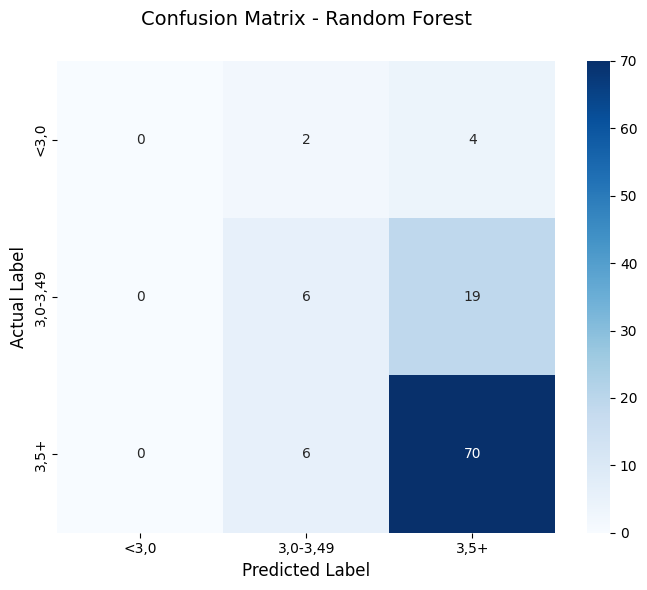

In [132]:
# evaluasi random forest
y_pred_rf_train = np.argmax(rf_proba_train, axis=1)
y_pred_rf_test  = np.argmax(rf_proba_test, axis=1)

evaluate_model(
    y_true=y_test.values,
    y_pred=y_pred_rf_test,
    model_name="Random Forest",
    labels_custom=ipk_labels,
    normalize=False
)


=== Logistic Regression Evaluation ===
Accuracy: 67.29%

Classification Report:
              precision    recall  f1-score   support

        <3,0       0.22      0.33      0.27         6
    3,0-3,49       0.46      0.48      0.47        25
        3,5+       0.81      0.76      0.78        76

    accuracy                           0.67       107
   macro avg       0.50      0.53      0.51       107
weighted avg       0.69      0.67      0.68       107



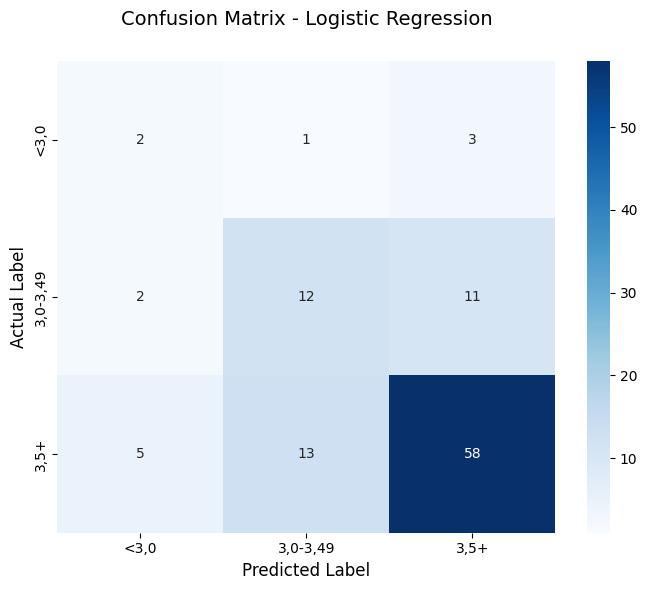

In [133]:
# evaluasi logistic regression
actual_lr = [row[-1] for row in test_logreg]
evaluate_model(actual_lr, y_pred_logreg_test, model_name="Logistic Regression", labels_custom=ipk_labels)

In [134]:
print(type(y_test.values[0]), y_test.values[:5])
print(type(y_pred_final[0]), y_pred_final[:5])

<class 'numpy.int64'> [2 2 2 1 2]
<class 'int'> [2, 2, 2, 1, 2]



=== Hybrid (RF + Logistic Regression) Evaluation ===
Accuracy: 71.96%

Classification Report:
              precision    recall  f1-score   support

        <3,0       0.00      0.00      0.00         6
    3,0-3,49       0.46      0.24      0.32        25
        3,5+       0.76      0.93      0.84        76

    accuracy                           0.72       107
   macro avg       0.41      0.39      0.38       107
weighted avg       0.64      0.72      0.67       107



c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Coretail\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

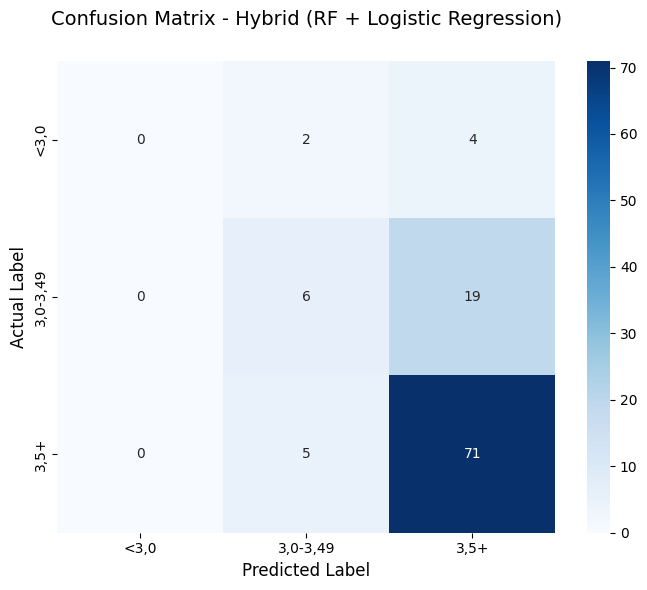

In [135]:
evaluate_model(
    y_true=y_test.values,
    y_pred=y_pred_final,
    model_name="Hybrid (RF + Logistic Regression)",
    labels_custom=ipk_labels,
    normalize=False
)

In [136]:
# Random forest feature importance (base model 1)

def compute_rf_feature_importance(forest, n_total_features):
    importance = np.zeros(n_total_features)
    
    def traverse(node):
        if isinstance(node, dict):
            idx = node['index']
            gain = node.get('gain', 0)
            importance[idx] += gain
            traverse(node['left'])
            traverse(node['right'])
    
    for tree in forest:
        traverse(tree)
    
    total = np.sum(importance)
    if total > 0:
        importance /= total
    return importance


In [137]:

# feature importance (base model 2)

def compute_logreg_feature_importance(models, feature_names=None):
    """Hitung importance rata-rata dari semua model OvR Logistic Regression"""
    # Ambil bobot tiap model OvR (models berisi list of weights)
    weights = np.array([np.abs(model[1:]) for model in models])  # skip bias di index 0
    mean_importance = np.mean(weights, axis=0)

    # Normalisasi
    mean_importance /= np.sum(mean_importance)

    print("\nFeature Importance (Logistic Regression OvR):")
    if feature_names is not None:
        for name, imp in zip(feature_names, mean_importance):
            print(f"{name:<25} → {imp:.4f}")
    else:
        for i, imp in enumerate(mean_importance):
            print(f"Feature {i+1}: {imp:.4f}")

    return mean_importance

In [138]:
# ambil feature importance
rf_importance = compute_rf_feature_importance(forest, len(X_train_resampled.columns))
# Buat array nama fitur & importance
feature_names = np.array(X_train_resampled.columns)
importances = np.array(rf_importance)

# Urutkan dari terbesar ke terkecil
sorted_idx = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importances = importances[sorted_idx]

# Cetak hasil terurut
print("\n Feature Importance (Random Forest) — Diurutkan:")
for f, imp in zip(sorted_features, sorted_importances):
    print(f"{f:<30} → {imp:.4f}")


 Feature Importance (Random Forest) — Diurutkan:
GS5                            → 0.0334
TM1                            → 0.0333
Academic year                  → 0.0331
GS3                            → 0.0314
TS4                            → 0.0305
TS3                            → 0.0303
TS1                            → 0.0300
TS2                            → 0.0294
HS1                            → 0.0276
SE3                            → 0.0274
Parental education             → 0.0273
Faculty_6                      → 0.0271
Learning time before COVID-19  → 0.0269
Learning time during COVID-19  → 0.0258
TM2                            → 0.0255
No. of Siblings                → 0.0255
SE4                            → 0.0243
GS1                            → 0.0238
ES4                            → 0.0236
GS2                            → 0.0235
SE1                            → 0.0232
HS4                            → 0.0227
Faculty_4                      → 0.0219
GS4                           

In [139]:
# Ambil hasil importance
logreg_importance = compute_logreg_feature_importance(models, X_train_resampled.columns)
# Urutkan dari yang terbesar ke terkecil
sorted_features = sorted(
    zip(X_train_resampled.columns, logreg_importance),
    key=lambda x: x[1],
    reverse=True
)

print("\n🌟 Feature Importance (Logistic Regression OvR) - Diurutkan:")
for name, imp in sorted_features:
    print(f"{name:<25} → {imp:.4f}")



Feature Importance (Logistic Regression OvR):
Academic year             → 0.0147
Age group                 → 0.0175
Learning time before COVID-19 → 0.0114
Learning time during COVID-19 → 0.0242
No. of Siblings           → 0.0122
Daily Internet usage      → 0.0150
Purpose of internet usage → 0.0201
Parental education        → 0.0125
GS1                       → 0.0083
GS2                       → 0.0123
GS3                       → 0.0059
GS4                       → 0.0058
GS5                       → 0.0245
ES1                       → 0.0065
ES2                       → 0.0046
ES3                       → 0.0158
ES4                       → 0.0198
TS1                       → 0.0157
TS2                       → 0.0087
TS3                       → 0.0064
TS4                       → 0.0117
TM1                       → 0.0144
TM2                       → 0.0096
TM3                       → 0.0069
HS1                       → 0.0107
HS2                       → 0.0191
HS3                       → 0.0093


In [ ]:
def compute_meta_feature_importance(meta_models, feature_names=None):
    """
    Menghitung rata-rata absolut bobot dari model meta-learner (OvR Logistic Regression)
    untuk melihat kontribusi masing-masing base model.
    """
    # Ambil bobot tiap model (kecuali bias di indeks 0)
    weights = np.array([np.abs(model[1:]) for model in meta_models])  # shape: [n_classes, n_features]
    
    # Hitung rata-rata per fitur di seluruh kelas
    mean_importance = np.mean(weights, axis=0)
    
    # Normalisasi agar total = 1
    mean_importance /= np.sum(mean_importance)
    
    # Tampilkan hasil
    print("Feature Importance (Meta Learner: RF vs LogReg):")
    if feature_names is not None:
        for name, imp in zip(feature_names, mean_importance):
            print(f"{name:<25} : {imp:.4f}")
    else:
        for i, imp in enumerate(mean_importance):
            print(f"Feature {i+1:<2} : {imp:.4f}")
    
    return mean_importance

In [141]:
# Buat array nama fitur & importance
feature_names = np.array(X_train_resampled.columns)
importances = np.array(rf_importance)

# Urutkan dari yang terbesar ke terkecil
sorted_idx = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importances = importances[sorted_idx]

# Ambil hanya 10 teratas
top_n = 10
sorted_features = sorted_features[:top_n]
sorted_importances = sorted_importances[:top_n]

# Cetak hasil
print("Feature Importance (Random Forest) — 10 Teratas:")
for f, imp in zip(sorted_features, sorted_importances):
    print(f"{f:<30} : {imp:.4f}")


Feature Importance (Random Forest) — 10 Teratas:
GS5                            : 0.0334
TM1                            : 0.0333
Academic year                  : 0.0331
GS3                            : 0.0314
TS4                            : 0.0305
TS3                            : 0.0303
TS1                            : 0.0300
TS2                            : 0.0294
HS1                            : 0.0276
SE3                            : 0.0274


In [142]:
# Urutkan dari yang terbesar ke terkecil
sorted_features = sorted(
    zip(X_train_resampled.columns, logreg_importance),
    key=lambda x: x[1],
    reverse=True
)[:10]  # ambil 10 teratas

print("Feature Importance (Logistic Regression OvR) — 10 Teratas:")
for name, imp in sorted_features:
    print(f"{name:<25} : {imp:.4f}")

Feature Importance (Logistic Regression OvR) — 10 Teratas:
Faculty_4                 : 0.0880
Faculty_6                 : 0.0761
Gender_2                  : 0.0535
Devices often use_3       : 0.0492
Devices often use_4       : 0.0485
Faculty_8                 : 0.0393
Parental occupation_4     : 0.0357
Parental occupation_2     : 0.0302
Location of residence_2   : 0.0283
Faculty_3                 : 0.0260


In [145]:
# Nama meta-feature (3 RF + 3 LogReg)
meta_feature_names = [
    "RF_Prob_Class_0",
    "RF_Prob_Class_1",
    "RF_Prob_Class_2",
    "LogReg_Prob_Class_0",
    "LogReg_Prob_Class_1",
    "LogReg_Prob_Class_2"
]

# Hitung feature importance meta learner
meta_importance = compute_meta_feature_importance(
    meta_models,
    feature_names=meta_feature_names
)


rf_contribution = meta_importance[:3].sum()
lr_contribution = meta_importance[3:].sum()

print(f"Kontribusi Random Forest     : {rf_contribution:.4f}")
print(f"Kontribusi Logistic Regression : {lr_contribution:.4f}")

Feature Importance (Meta Learner: RF vs LogReg):
RF_Prob_Class_0           : 0.3027
RF_Prob_Class_1           : 0.3102
RF_Prob_Class_2           : 0.3022
LogReg_Prob_Class_0       : 0.0300
LogReg_Prob_Class_1       : 0.0096
LogReg_Prob_Class_2       : 0.0453
Kontribusi Random Forest     : 0.9151
Kontribusi Logistic Regression : 0.0849
